# Imports & Loading the data

In [ ]:
  import torch, random, numpy as np
  torch.manual_seed(42)
  torch.cuda.manual_seed_all(42)
  np.random.seed(42)
  random.seed(42)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False

In [1]:
#1 - Imports & paths
from pathlib import Path
import pandas as pd

ROOT = Path('/data0/b2ai-voice/2.0.0')
SPEC = ROOT / 'spectrogram.parquet'
PHEN = ROOT / 'phenotype.tsv'
print(SPEC.exists(), PHEN.exists())


True True


In [2]:
#2 - Load files (safe row-group read)
import pyarrow.parquet as pq

pheno = pd.read_csv(PHEN, sep='\t')

pf = pq.ParquetFile(SPEC)
parts = []
for i in range(pf.num_row_groups):
    parts.append(pf.read_row_group(i, columns=['participant_id','session_id','task_name','spectrogram']).to_pandas())
spec = pd.concat(parts, ignore_index=True)

print("pheno:", pheno.shape, "spec:", spec.shape)
spec.head(2)


pheno: (442, 1109) spec: (16738, 4)


,participant_id,session_id,task_name,spectrogram
0,004d42e9,07031CC3,Animal-fluency,"[[3.2496545, 0.8633412, 0.29140452, -15.261607..."
1,004d42e9,07031CC3,Cinderella-Story,"[[25.801548, 24.044765, 21.460907, 19.336544, ..."


In [3]:
# #3 - Build Dementia label (alz_dementia_mci)

LABEL_SRC_COL = "alz_dementia_mci"
LABEL_COL = "dementia_label"

pheno[LABEL_COL] = pheno[LABEL_SRC_COL].map({"Checked": 1, "Unchecked": 0})

labels = pheno[["participant_id", LABEL_COL]].dropna().copy()
labels[LABEL_COL] = labels[LABEL_COL].astype(int)

print(labels[LABEL_COL].value_counts())


dementia_label
0    400
1     42
Name: count, dtype: int64


In [4]:
# #4 - Merge (Dementia)

data = spec.merge(labels, on="participant_id", how="inner")
print("merged:", data.shape)

print("\nDementia label counts after merge:")
print(data["dementia_label"].value_counts())

data[["participant_id", "session_id", "task_name", "dementia_label"]].head(3)


merged: (16738, 5)

Dementia label counts after merge:
dementia_label
0    14672
1     2066
Name: count, dtype: int64


,participant_id,session_id,task_name,dementia_label
0,004d42e9,07031CC3,Animal-fluency,1
1,004d42e9,07031CC3,Cinderella-Story,1
2,004d42e9,07031CC3,Diadochokinesis-KA,1


# EDA

In [14]:
#5 - Inspect spectrogram structure (fixed)
import numpy as np

# We now know: 201 frequency bins × 3002 time frames (but stored as object array)
# Let's properly stack one sample and verify

sample = data['spectrogram'].iloc[0]
arr = np.stack(sample)  # Stack the 201 arrays into a proper 2D array
print(f"Single spectrogram shape: {arr.shape}")
print(f"Dtype: {arr.dtype}, Min: {arr.min():.2f}, Max: {arr.max():.2f}")

# Check a few more to confirm consistency
print("\n--- Checking 5 samples ---")
for i in range(5):
    s = data['spectrogram'].iloc[i]
    stacked = np.stack(s)
    print(f"Sample {i}: shape={stacked.shape}")

# Check shape distribution across all data
print("\n--- Shape distribution across dataset ---")
shapes = data['spectrogram'].apply(lambda x: (len(x), len(x[0])))
print(f"Unique shapes: {shapes.nunique()}")
print(shapes.value_counts().head(10))

Single spectrogram shape: (201, 3002)
Dtype: float32, Min: -33.99, Max: 46.01

--- Checking 5 samples ---
Sample 0: shape=(201, 3002)
Sample 1: shape=(201, 12225)
Sample 2: shape=(201, 214)
Sample 3: shape=(201, 197)
Sample 4: shape=(201, 434)

--- Shape distribution across dataset ---
Unique shapes: 2586
spectrogram
(201, 1502)    1274
(201, 607)      321
(201, 3002)     243
(201, 1501)     235
(201, 606)       69
(201, 3001)      40
(201, 255)       39
(201, 218)       39
(201, 187)       38
(201, 196)       38
Name: count, dtype: int64


Time dimension statistics:
  Min: 6
  Max: 16628
  Mean: 934.5
  Median: 597.0
  Std: 1087.7

Percentiles:
  25th: 297
  50th: 597
  75th: 1304
  90th: 1697
  95th: 3002
  99th: 4901


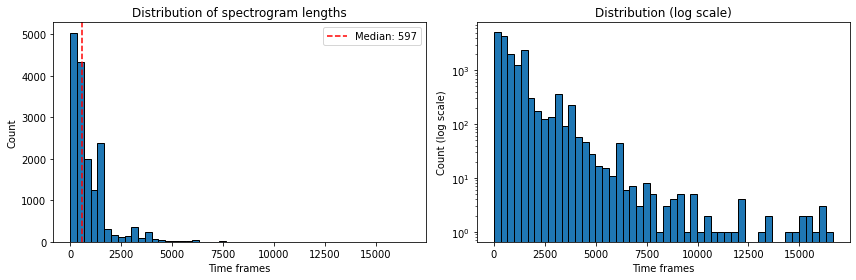


Total samples: 16738


In [15]:
#6 - Analyze time dimension distribution
import numpy as np
import matplotlib.pyplot as plt

# Extract time dimensions
time_dims = data['spectrogram'].apply(lambda x: len(x[0]))

print("Time dimension statistics:")
print(f"  Min: {time_dims.min()}")
print(f"  Max: {time_dims.max()}")
print(f"  Mean: {time_dims.mean():.1f}")
print(f"  Median: {time_dims.median():.1f}")
print(f"  Std: {time_dims.std():.1f}")

# Percentiles to guide truncation/padding decision
percentiles = [25, 50, 75, 90, 95, 99]
print("\nPercentiles:")
for p in percentiles:
    print(f"  {p}th: {np.percentile(time_dims, p):.0f}")

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(time_dims, bins=50, edgecolor='black')
axes[0].set_xlabel('Time frames')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of spectrogram lengths')
axes[0].axvline(time_dims.median(), color='r', linestyle='--', label=f'Median: {time_dims.median():.0f}')
axes[0].legend()

# Log scale for better visualization of spread
axes[1].hist(time_dims, bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Time frames')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Distribution (log scale)')

plt.tight_layout()
plt.savefig('time_distribution.png', dpi=150)
plt.show()

print(f"\nTotal samples: {len(time_dims)}")

In [5]:
# #7 - Investigate short recordings and length vs label relationship (Dementia)
import numpy as np
import pandas as pd

LABEL_COL = "dementia_label"

data["time_frames"] = data["spectrogram"].apply(lambda x: len(x[0]))

short_threshold = 100
short_recordings = data[data["time_frames"] < short_threshold]
print(f"Recordings with < {short_threshold} frames: {len(short_recordings)}")
print("Their task distribution:")
print(short_recordings["task_name"].value_counts())
print("\nTheir dementia label distribution:")
print(short_recordings[LABEL_COL].value_counts())

print("\n--- Time frames by dementia status ---")
for label in [0, 1]:
    subset = data[data[LABEL_COL] == label]["time_frames"]
    print(f"dementia={label}: mean={subset.mean():.1f}, median={subset.median():.1f}, n={len(subset)}")

print("\n--- Task distribution ---")
print(data["task_name"].value_counts())

print("\n--- Tasks by dementia status ---")
print(pd.crosstab(data["task_name"], data[LABEL_COL]))


Recordings with < 100 frames: 184
Their task distribution:
task_name
Respiration-and-cough-Breath-2               20
Respiration-and-cough-Cough-2                20
Respiration-and-cough-FiveBreaths-3          20
Respiration-and-cough-FiveBreaths-4          20
Respiration-and-cough-ThreeQuickBreaths-2    19
Free-speech-2                                12
Free-speech-3                                 8
Story-recall                                  8
Cape-V-sentences-2                            6
Cinderella-Story                              6
Free-speech-1                                 5
Cape-V-sentences-3                            4
Respiration-and-cough-Cough-1                 3
Cape-V-sentences-4                            3
Diadochokinesis-KA                            3
Diadochokinesis-TA                            3
Rainbow-Passage                               3
Loudness                                      2
Respiration-and-cough-Breath-1                2
Cape-V-sentences-6 

# Select HIGH dementia-ratio tasks + process raw spectrograms + split + Visualization

In [6]:
# #8 - Select high-prevalence dementia tasks + process raw spectrograms
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split

LABEL_COL = "dementia_label"
HIGH_TASKS = [
    "Cinderella-Story",
    "Productive-Vocabulary-1",
    "Productive-Vocabulary-2",
    "Productive-Vocabulary-3",
    "Productive-Vocabulary-4",
    "Productive-Vocabulary-5",
    "Productive-Vocabulary-6",
    "Random-Item-Generation",
    "Word-color-Stroop",
]

min_time_frames = 100

data_high = data[
    (data["task_name"].isin(HIGH_TASKS)) &
    (data["time_frames"] >= min_time_frames)
].copy()

print("Total samples:", len(data_high))
print("Dementia samples:", int(data_high[LABEL_COL].sum()))
print("Non-dementia samples:", int((data_high[LABEL_COL] == 0).sum()))
print("Dementia ratio:", float(data_high[LABEL_COL].mean()))

print("\nParticipants total:", data_high["participant_id"].nunique())
print("Participants dementia:", data_high[data_high[LABEL_COL] == 1]["participant_id"].nunique())
print("Participants non-dementia:", data_high[data_high[LABEL_COL] == 0]["participant_id"].nunique())

print("\nSamples per task:")
print(data_high["task_name"].value_counts())

TARGET_SEQ_LEN = 1024

def process_spectrogram_raw(spec_raw, target_len=1024):
    spec = np.stack(spec_raw).astype(np.float32)
    _, time_len = spec.shape

    if time_len < target_len:
        spec = np.pad(spec, ((0, 0), (0, target_len - time_len)), mode="reflect")
    elif time_len > target_len:
        start = (time_len - target_len) // 2
        spec = spec[:, start:start + target_len]

    return spec

X_list = []
for _, row in tqdm(data_high.iterrows(), total=len(data_high), desc="Processing"):
    X_list.append(process_spectrogram_raw(row["spectrogram"], TARGET_SEQ_LEN))

X_raw = np.stack(X_list)
y_raw = data_high[LABEL_COL].values.astype(int)
participants_raw = data_high["participant_id"].values

print("\nProcessed X_raw shape:", X_raw.shape)

# Participant-level split
unique_parts = np.unique(participants_raw)
part_labels = np.array([y_raw[participants_raw == p][0] for p in unique_parts])

train_parts, test_parts = train_test_split(
    unique_parts, test_size=0.2, stratify=part_labels, random_state=42
)

train_mask = np.isin(participants_raw, train_parts)
test_mask = np.isin(participants_raw, test_parts)

X_train = X_raw[train_mask]
y_train = y_raw[train_mask]
parts_train = participants_raw[train_mask]

X_test = X_raw[test_mask]
y_test = y_raw[test_mask]
parts_test = participants_raw[test_mask]

print("Train samples:", len(X_train), "Train participants:", len(train_parts), "Train dementia rate:", float(y_train.mean()))
print("Test samples:", len(X_test), "Test participants:", len(test_parts), "Test dementia rate:", float(y_test.mean()))

assert len(set(train_parts) & set(test_parts)) == 0
print("No participant overlap between train and test.")


Total samples: 1349
Dementia samples: 484
Non-dementia samples: 865
Dementia ratio: 0.3587842846553002

Participants total: 112
Participants dementia: 41
Participants non-dementia: 71

Samples per task:
task_name
Productive-Vocabulary-4    151
Word-color-Stroop          151
Productive-Vocabulary-3    151
Productive-Vocabulary-5    151
Productive-Vocabulary-1    150
Productive-Vocabulary-6    150
Productive-Vocabulary-2    150
Random-Item-Generation     150
Cinderella-Story           145
Name: count, dtype: int64


Processing: 100%|██████████| 1349/1349 [00:01<00:00, 1180.11it/s]



Processed X_raw shape: (1349, 201, 1024)
Train samples: 1099 Train participants: 89 Train dementia rate: 0.36760691537761603
Test samples: 250 Test participants: 23 Test dementia rate: 0.32
No participant overlap between train and test.


# Modelling

In [7]:
# #9 - Audio Spectrogram Transformer (AST) for dementia
import torch
import torch.nn as nn
import numpy as np
from transformers import ASTModel
from scipy.ndimage import zoom
from tqdm import tqdm

# Resize spectrograms to AST format (128 × 1024)
def resize_spectrogram(spec, target_mel=128, target_time=1024):
    mel_ratio = target_mel / spec.shape[0]
    time_ratio = target_time / spec.shape[1]
    return zoom(spec, (mel_ratio, time_ratio), order=1).astype(np.float32)

# Resize train
X_train_ast = np.stack([
    resize_spectrogram(x) for x in tqdm(X_train, desc="Resize train")
])

# Resize test
X_test_ast = np.stack([
    resize_spectrogram(x) for x in tqdm(X_test, desc="Resize test")
])

print("Resized shapes:", X_train_ast.shape, X_test_ast.shape)

# Normalize using train statistics
mean = X_train_ast.mean()
std = X_train_ast.std()
X_train_ast = (X_train_ast - mean) / (std + 1e-8)
X_test_ast = (X_test_ast - mean) / (std + 1e-8)

print("Train normalized mean/std:", X_train_ast.mean(), X_train_ast.std())

# Dataset
class ASTDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, pids, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.pids = np.array(pids)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if np.random.rand() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.rand() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        return {
            "inputs": x,
            "labels": self.y[idx],
            "participant": self.pids[idx]
        }

train_ds = ASTDataset(X_train_ast, y_train, parts_train, augment=True)
test_ds = ASTDataset(X_test_ast, y_test, parts_test, augment=False)

# Balanced sampler
class_counts = np.bincount(y_train)
weights = 1.0 / class_counts
sample_weights = weights[y_train]
sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

train_loader = torch.utils.data.DataLoader(
    train_ds, batch_size=8, sampler=sampler, num_workers=4, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=8, shuffle=False, num_workers=4, pin_memory=True
)

print("Batches:", len(train_loader), len(test_loader))

# AST classifier
class ASTClassifier(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.ast = ASTModel.from_pretrained(
            "MIT/ast-finetuned-audioset-10-10-0.4593"
        )
        h = self.ast.config.hidden_size
        self.classifier = nn.Sequential(
            nn.LayerNorm(h),
            nn.Linear(h, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, 1024, 128)
        out = self.ast(input_values=x)
        return self.classifier(out.pooler_output)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_ast = ASTClassifier().to(device)

total_params = sum(p.numel() for p in model_ast.parameters())
trainable_params = sum(p.numel() for p in model_ast.parameters() if p.requires_grad)
print("Params:", total_params, "Trainable:", trainable_params)

# Sanity check
with torch.no_grad():
    batch = next(iter(train_loader))
    out = model_ast(batch["inputs"].to(device))
    print("Forward pass:", batch["inputs"].shape, "->", out.shape)


Resize test: 100%|██████████| 250/250 [00:00<00:00, 468.92it/s]


Resized shapes: (1099, 128, 1024) (250, 128, 1024)
Train normalized mean/std: -4.277813e-08 1.0000002
Batches: 138 32
Params: 86386178 Trainable: 86386178
Forward pass: torch.Size([8, 128, 1024]) -> torch.Size([8, 2])


In [8]:
# #10 - Train pre-trained AST (Dementia)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from tqdm import tqdm
import copy
import time

def get_optimizer_groups(model, lr_backbone=5e-6, lr_head=5e-4, weight_decay=0.01):
    backbone_params = []
    head_params = []
    for name, param in model.named_parameters():
        if "classifier" in name:
            head_params.append(param)
        else:
            backbone_params.append(param)
    return [
        {"params": backbone_params, "lr": lr_backbone, "weight_decay": weight_decay},
        {"params": head_params, "lr": lr_head, "weight_decay": weight_decay},
    ]

optimizer = torch.optim.AdamW(
    get_optimizer_groups(model_ast, lr_backbone=5e-6, lr_head=5e-4),
    betas=(0.9, 0.999),
)

NUM_EPOCHS = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

# class weights from y_train
cc = np.bincount(y_train)
cw = (cc.sum() / (2.0 * cc)).astype(np.float32)
class_weights = torch.tensor(cw, dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights, gamma=2.0)

def evaluate_ast(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []

    with torch.no_grad():
        for batch in loader:
            inputs = batch["inputs"].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch["labels"].numpy())
            all_parts.extend(batch["participant"])

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)

    # participant-level aggregation
    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        m = all_parts == p
        part_probs.append(all_probs[m].mean())
        part_labels.append(all_labels[m][0])

    part_probs = np.array(part_probs)
    part_labels = np.array(part_labels)

    if len(np.unique(part_labels)) > 1:
        part_auc = roc_auc_score(part_labels, part_probs)
        fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
        opt_idx = np.argmax(tpr - fpr)
        opt_thresh = thresholds[opt_idx]
    else:
        part_auc = 0.5
        opt_thresh = 0.5

    preds_05 = (part_probs >= 0.5).astype(int)
    preds_opt = (part_probs >= opt_thresh).astype(int)

    return {
        "part_auc": float(part_auc),
        "part_f1": float(f1_score(part_labels, preds_05, zero_division=0)),
        "part_f1_opt": float(f1_score(part_labels, preds_opt, zero_division=0)),
        "part_recall_opt": float(recall_score(part_labels, preds_opt, zero_division=0)),
        "part_prec_opt": float(precision_score(part_labels, preds_opt, zero_division=0)),
        "optimal_thresh": float(opt_thresh),
    }

best_f1 = 0.0
best_auc = 0.0
best_state = None
best_epoch = 0
best_metrics = None
patience = 15
patience_counter = 0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_ast.train()
    total_loss = 0.0

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        inputs = batch["inputs"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model_ast(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_ast.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    avg_loss = total_loss / max(1, len(train_loader))

    metrics = evaluate_ast(model_ast, test_loader, device)

    score = 0.4 * metrics["part_auc"] + 0.6 * metrics["part_f1_opt"]
    best_score = 0.4 * best_auc + 0.6 * best_f1

    improved = score > best_score + 0.01
    if improved:
        best_f1 = metrics["part_f1_opt"]
        best_auc = metrics["part_auc"]
        best_state = copy.deepcopy(model_ast.state_dict())
        best_epoch = epoch + 1
        best_metrics = metrics.copy()
        patience_counter = 0
    else:
        patience_counter += 1

    lr_backbone = optimizer.param_groups[0]["lr"]
    lr_head = optimizer.param_groups[1]["lr"]

    print(
        f"Epoch {epoch+1:02d} | loss {avg_loss:.4f} | "
        f"AUC {metrics['part_auc']:.3f} | F1@0.5 {metrics['part_f1']:.3f} | "
        f"F1opt {metrics['part_f1_opt']:.3f} | rec {metrics['part_recall_opt']:.3f} | "
        f"prec {metrics['part_prec_opt']:.3f} | thr {metrics['optimal_thresh']:.3f} | "
        f"lr {lr_backbone:.1e}/{lr_head:.1e}"
        + (" BEST" if improved else "")
    )

    if patience_counter >= patience:
        break

elapsed = (time.time() - start_time) / 60.0

model_ast.load_state_dict(best_state)

print("\nBest epoch:", best_epoch)
print("Minutes:", elapsed)
print("Best participant AUC:", best_metrics["part_auc"])
print("Best participant F1@0.5:", best_metrics["part_f1"])
print("Best participant F1opt:", best_metrics["part_f1_opt"], "thr:", best_metrics["optimal_thresh"])
print("Best participant recall/precision:", best_metrics["part_recall_opt"], best_metrics["part_prec_opt"])


Epoch 01 | loss 0.1866 | AUC 0.642 | F1@0.5 0.516 | F1opt 0.667 | rec 0.750 | prec 0.600 | thr 0.689 | lr 5.0e-06/5.0e-04 BEST


Epoch 02 | loss 0.1422 | AUC 0.625 | F1@0.5 0.556 | F1opt 0.667 | rec 0.625 | prec 0.714 | thr 0.526 | lr 5.0e-06/5.0e-04


Epoch 03 | loss 0.1094 | AUC 0.667 | F1@0.5 0.500 | F1opt 0.714 | rec 0.625 | prec 0.833 | thr 0.445 | lr 5.0e-06/5.0e-04 BEST


Epoch 04 | loss 0.1061 | AUC 0.708 | F1@0.5 0.545 | F1opt 0.667 | rec 0.625 | prec 0.714 | thr 0.749 | lr 4.9e-06/4.9e-04


Epoch 05 | loss 0.0630 | AUC 0.592 | F1@0.5 0.545 | F1opt 0.400 | rec 0.250 | prec 1.000 | thr 0.859 | lr 4.9e-06/4.9e-04


...

Epoch 14 | loss 0.0112 | AUC 0.675 | F1@0.5 0.400 | F1opt 0.667 | rec 0.750 | prec 0.600 | thr 0.416 | lr 4.1e-06/4.1e-04


Epoch 15 | loss 0.0252 | AUC 0.742 | F1@0.5 0.588 | F1opt 0.615 | rec 0.500 | prec 0.800 | thr 0.663 | lr 4.0e-06/4.0e-04


Epoch 16 | loss 0.0173 | AUC 0.683 | F1@0.5 0.462 | F1opt 0.667 | rec 0.875 | prec 0.538 | thr 0.182 | lr 3.9e-06/3.8e-04


Epoch 17 | loss 0.0148 | AUC 0.675 | F1@0.5 0.533 | F1opt 0.588 | rec 0.625 | prec 0.556 | thr 0.458 | lr 3.7e-06/3.7e-04


Epoch 18 | loss 0.0145 | AUC 0.700 | F1@0.5 0.364 | F1opt 0.609 | rec 0.875 | prec 0.467 | thr 0.072 | lr 3.6e-06/3.6e-04

Best epoch: 3
Minutes: 30.020710190137226
Best participant AUC: 0.6666666666666667
Best participant F1@0.5: 0.5
Best participant F1opt: 0.7142857142857143 thr: 0.4453519582748413
Best participant recall/precision: 0.625 0.8333333333333334


In [10]:
# #11 - 5-Fold Cross-Validation with AST (Dementia, selected tasks)
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, roc_curve
from scipy.ndimage import zoom
from tqdm import tqdm
import copy
import time

def resize_spectrogram_cv(spec, target_mel=128, target_time=1024):
    mel_ratio = target_mel / spec.shape[0]
    time_ratio = target_time / spec.shape[1]
    return zoom(spec, (mel_ratio, time_ratio), order=1).astype(np.float32)

class ASTDatasetCV(torch.utils.data.Dataset):
    def __init__(self, X, y, participants, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.participants = np.array(participants)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()
        if self.augment:
            if np.random.rand() < 0.5:
                t = np.random.randint(50, 150)
                t0 = np.random.randint(0, max(1, x.shape[1] - t))
                x[:, t0:t0+t] = 0
            if np.random.rand() < 0.5:
                f = np.random.randint(10, 30)
                f0 = np.random.randint(0, max(1, x.shape[0] - f))
                x[f0:f0+f, :] = 0
        return {"inputs": x, "labels": self.y[idx], "participant": self.participants[idx]}

class FocalLossCV(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce)
        return (((1 - pt) ** self.gamma) * ce).mean()

def evaluate_fold(model, loader, device):
    model.eval()
    all_probs, all_labels, all_parts = [], [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch["inputs"].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(batch["labels"].numpy())
            all_parts.extend(batch["participant"])

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_parts = np.array(all_parts)

    unique_parts = np.unique(all_parts)
    part_probs, part_labels = [], []
    for p in unique_parts:
        m = all_parts == p
        part_probs.append(all_probs[m].mean())
        part_labels.append(all_labels[m][0])

    return np.array(part_probs), np.array(part_labels), unique_parts


unique_participants = np.unique(participants_raw)
participant_labels = np.array([y_raw[participants_raw == p][0] for p in unique_participants])

N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

fold_results = []
all_oof_probs = np.zeros(len(unique_participants), dtype=np.float32)
all_oof_labels = participant_labels.astype(np.int64).copy()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

total_start = time.time()

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(unique_participants, participant_labels),
                                                 total=N_FOLDS, desc="CV folds")):
    train_parts_fold = unique_participants[train_idx]
    val_parts_fold = unique_participants[val_idx]

    train_mask = np.isin(participants_raw, train_parts_fold)
    val_mask = np.isin(participants_raw, val_parts_fold)

    X_train_fold = X_raw[train_mask]
    y_train_fold = y_raw[train_mask]
    parts_train_fold = participants_raw[train_mask]

    X_val_fold = X_raw[val_mask]
    y_val_fold = y_raw[val_mask]
    parts_val_fold = participants_raw[val_mask]

    X_train_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_train_fold, desc="resize train", leave=False)])
    X_val_ast_fold = np.stack([resize_spectrogram_cv(x) for x in tqdm(X_val_fold, desc="resize val", leave=False)])

    m = X_train_ast_fold.mean()
    s = X_train_ast_fold.std()
    X_train_ast_fold = (X_train_ast_fold - m) / (s + 1e-8)
    X_val_ast_fold = (X_val_ast_fold - m) / (s + 1e-8)

    train_ds_fold = ASTDatasetCV(X_train_ast_fold, y_train_fold, parts_train_fold, augment=True)
    val_ds_fold = ASTDatasetCV(X_val_ast_fold, y_val_fold, parts_val_fold, augment=False)

    cc = np.bincount(y_train_fold)
    w = 1.0 / cc
    sample_weights = w[y_train_fold]
    sampler = torch.utils.data.WeightedRandomSampler(sample_weights, len(sample_weights))

    train_loader_fold = torch.utils.data.DataLoader(train_ds_fold, batch_size=8, sampler=sampler, num_workers=4, pin_memory=True)
    val_loader_fold = torch.utils.data.DataLoader(val_ds_fold, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

    # FIX: your ASTClassifier only takes num_classes
    model_fold = ASTClassifier(num_classes=2).to(device)

    backbone_params = [p for n, p in model_fold.named_parameters() if "classifier" not in n]
    head_params = [p for n, p in model_fold.named_parameters() if "classifier" in n]
    optimizer_fold = torch.optim.AdamW([
        {"params": backbone_params, "lr": 5e-6, "weight_decay": 0.01},
        {"params": head_params, "lr": 5e-4, "weight_decay": 0.01},
    ])
    scheduler_fold = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fold, T_max=30, eta_min=1e-7)

    cc = np.bincount(y_train_fold)
    cw = (cc.sum() / (2.0 * cc)).astype(np.float32)
    class_weights_fold = torch.tensor(cw, dtype=torch.float32).to(device)
    criterion_fold = FocalLossCV(alpha=class_weights_fold, gamma=2.0)

    best_score = 0.0
    best_state = None
    patience = 10
    patience_counter = 0

    for epoch in tqdm(range(30), desc=f"fold {fold+1} epochs", leave=False):
        model_fold.train()
        for batch in train_loader_fold:
            inputs = batch["inputs"].to(device)
            labels = batch["labels"].to(device)

            optimizer_fold.zero_grad()
            outputs = model_fold(inputs)
            loss = criterion_fold(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_fold.parameters(), 1.0)
            optimizer_fold.step()

        scheduler_fold.step()

        part_probs, part_labels, _ = evaluate_fold(model_fold, val_loader_fold, device)

        if len(np.unique(part_labels)) > 1:
            auc = roc_auc_score(part_labels, part_probs)
            fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
            opt_idx = np.argmax(tpr - fpr)
            opt_thresh = thresholds[opt_idx]
            preds_opt = (part_probs >= opt_thresh).astype(int)
            f1_opt = f1_score(part_labels, preds_opt, zero_division=0)
        else:
            auc, f1_opt = 0.5, 0.0

        score = 0.4 * auc + 0.6 * f1_opt
        if score > best_score + 0.01:
            best_score = score
            best_state = copy.deepcopy(model_fold.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    model_fold.load_state_dict(best_state)
    part_probs, part_labels, val_pids = evaluate_fold(model_fold, val_loader_fold, device)

    torch.save(model_fold.state_dict(), f"ast_dementia_fold{fold+1}.pt")

    for i, pid in enumerate(val_pids):
        idx_global = np.where(unique_participants == pid)[0][0]
        all_oof_probs[idx_global] = part_probs[i]

    fold_auc = roc_auc_score(part_labels, part_probs)
    fpr, tpr, thresholds = roc_curve(part_labels, part_probs)
    opt_idx = np.argmax(tpr - fpr)
    fold_thresh = thresholds[opt_idx]
    fold_preds = (part_probs >= fold_thresh).astype(int)

    fold_results.append({
        "fold": fold + 1,
        "auc": float(fold_auc),
        "f1_opt": float(f1_score(part_labels, fold_preds, zero_division=0)),
        "recall_opt": float(recall_score(part_labels, fold_preds, zero_division=0)),
        "precision_opt": float(precision_score(part_labels, fold_preds, zero_division=0)),
        "threshold": float(fold_thresh),
    })

    del model_fold, optimizer_fold, train_ds_fold, val_ds_fold
    torch.cuda.empty_cache()

total_time = time.time() - total_start

print("\nFold results:")
for r in fold_results:
    print(r)

aucs = [r["auc"] for r in fold_results]
f1s = [r["f1_opt"] for r in fold_results]
recalls = [r["recall_opt"] for r in fold_results]
precs = [r["precision_opt"] for r in fold_results]

print("Mean AUC:", float(np.mean(aucs)), "Std AUC:", float(np.std(aucs)))
print("Mean F1_opt:", float(np.mean(f1s)), "Std F1_opt:", float(np.std(f1s)))
print("Mean Recall:", float(np.mean(recalls)), "Mean Precision:", float(np.mean(precs)))

oof_auc = roc_auc_score(all_oof_labels, all_oof_probs)
fpr, tpr, thresholds = roc_curve(all_oof_labels, all_oof_probs)
opt_idx = np.argmax(tpr - fpr)
oof_thresh = thresholds[opt_idx]
oof_preds = (all_oof_probs >= oof_thresh).astype(int)

print("\nOOF AUC:", float(oof_auc))
print("OOF F1_opt:", float(f1_score(all_oof_labels, oof_preds, zero_division=0)), "thr:", float(oof_thresh))
print("OOF recall:", float(recall_score(all_oof_labels, oof_preds, zero_division=0)))
print("OOF precision:", float(precision_score(all_oof_labels, oof_preds, zero_division=0)))
print("Total CV minutes:", total_time / 60.0)


resize train:  98%|█████████▊| 1052/1073 [00:02<00:00, 446.29it/s]
                                                                  
resize val:  99%|█████████▉| 273/276 [00:00<00:00, 446.70it/s]
                                                              
resize train:  96%|█████████▋| 1009/1046 [00:02<00:00, 397.93it/s]
                                                                  
resize val:  89%|████████▉ | 269/303 [00:00<00:00, 437.65it/s]
                                                              
resize train: 100%|██████████| 1054/1054 [00:02<00:00, 414.18it/s]
                                                                  
resize val:  93%|█████████▎| 274/295 [00:00<00:00, 440.12it/s]
                                                              
resize train:  98%|█████████▊| 1093/1117 [00:02<00:00, 467.74it/s]
                                                                  
resize val:  84%|████████▎ | 194/232 [00:00<00:00, 477.94it/s]
                       


Fold results:
{'fold': 1, 'auc': 0.9206349206349207, 'f1_opt': 0.8421052631578947, 'recall_opt': 0.8888888888888888, 'precision_opt': 0.8, 'threshold': 0.37452149391174316}
{'fold': 2, 'auc': 0.625, 'f1_opt': 0.6153846153846154, 'recall_opt': 0.5, 'precision_opt': 0.8, 'threshold': 0.5432270765304565}
{'fold': 3, 'auc': 0.8125, 'f1_opt': 0.7692307692307693, 'recall_opt': 0.625, 'precision_opt': 1.0, 'threshold': 0.6482992768287659}
{'fold': 4, 'auc': 0.8571428571428572, 'f1_opt': 0.8, 'recall_opt': 0.75, 'precision_opt': 0.8571428571428571, 'threshold': 0.5741040706634521}
{'fold': 5, 'auc': 0.8214285714285714, 'f1_opt': 0.7777777777777778, 'recall_opt': 0.875, 'precision_opt': 0.7, 'threshold': 0.38574570417404175}
Mean AUC: 0.80734126984127 Std AUC: 0.09878163053736286
Mean F1_opt: 0.7608996851102114 Std F1_opt: 0.07700921116659076
Mean Recall: 0.7277777777777777 Mean Precision: 0.8314285714285715

OOF AUC: 0.7794572311920303
OOF F1_opt: 0.6666666666666666 thr: 0.5432270765304565
OO

In [1]:
# CI calculation (ddof=1) - Dementia Selected Tasks
from scipy import stats
import numpy as np

aucs = [0.9206, 0.625, 0.8125, 0.8571, 0.8214]
f1s = [0.8421, 0.6154, 0.7692, 0.800, 0.7778]
recalls = [0.8889, 0.500, 0.625, 0.750, 0.875]
precs = [0.800, 0.800, 1.000, 0.857, 0.700]

n = 5
t_crit = stats.t.ppf(0.975, df=n - 1)

print("Dementia Selected Tasks — Per-fold summary (ddof=1)")
for name, arr in [("AUC", aucs), ("F1", f1s), ("Recall", recalls), ("Precision", precs)]:
    m = np.mean(arr)
    sd = np.std(arr, ddof=1)
    se = sd / np.sqrt(n)
    ci_lo = m - t_crit * se
    ci_hi = m + t_crit * se
    print(f"  {name}: {m:.4f} +/- {sd:.4f} [{ci_lo:.4f}, {ci_hi:.4f}]")

Dementia Selected Tasks — Per-fold summary (ddof=1)
  AUC: 0.8073 +/- 0.1104 [0.6702, 0.9444]
  F1: 0.7609 +/- 0.0861 [0.6540, 0.8678]
  Recall: 0.7278 +/- 0.1663 [0.5213, 0.9342]
  Precision: 0.8314 +/- 0.1099 [0.6949, 0.9679]
